In [1]:
import warnings
import pandas as pd
from datetime import date
from dateutil.relativedelta import relativedelta
from tqdm.notebook import tqdm
from gridstatus import CAISO

warnings.filterwarnings('ignore')

## Pull CAISO hourly system load

Uses `get_load_hourly` which hits the CAISO OASIS API — data available back to **2015**.

We filter for the `CA ISO-TAC` row, which is the total CAISO system load in MW.

In [2]:
START = date(2019, 1, 1)
END   = date(2024, 12, 31)
OUTPUT = '../../data/raw/caiso_hourly.csv'

In [3]:
import os
os.makedirs('../../data/raw', exist_ok=True)

caiso = CAISO()

# Iterate month-by-month to keep each request small
all_frames = []
cur = START.replace(day=1)
months = []
while cur <= END:
    nxt = cur + relativedelta(months=1)
    months.append((cur.isoformat(), nxt.isoformat()))
    cur = nxt

for ms, me in tqdm(months, desc='Fetching hourly load'):
    try:
        df = caiso.get_load_hourly(start=ms, end=me)
        # Keep only the CA ISO-TAC row (total CAISO system load)
        ca_total = df[df['TAC Area Name'] == 'CA ISO-TAC'][['Interval Start', 'Load']].copy()
        ca_total.columns = ['datetime', 'load_mw']
        all_frames.append(ca_total)
    except Exception as e:
        print(f'  {ms}: {e}')

hourly = pd.concat(all_frames, ignore_index=True)
hourly = hourly.sort_values('datetime').drop_duplicates('datetime').reset_index(drop=True)

hourly.to_csv(OUTPUT, index=False)
print(f'Saved {len(hourly):,} rows → {OUTPUT}')
hourly.head()

Fetching hourly load:   0%|          | 0/72 [00:00<?, ?it/s]

2026-06-01 14:11:02 - DEBUG - Dataset config: {'query': {'path': 'SingleZip', 'resultformat': 6, 'queryname': 'SLD_FCST', 'version': 1}, 'params': {'market_run_id': ['7DA', '2DA', 'DAM', 'ACTUAL', 'RTM'], 'execution_type': [None, 'RTPD', 'RTD']}}
2026-06-01 14:11:02 - INFO - Fetching URL: http://oasis.caiso.com/oasisapi/SingleZip?resultformat=6&queryname=SLD_FCST&version=1&market_run_id=ACTUAL&startdatetime=20190101T08:00-0000&enddatetime=20190201T08:00-0000
2026-06-01 14:11:04 - DEBUG - Found 1 files: ['20190101_20190201_SLD_FCST_ACTUAL_20260601_12_11_03_v1.csv']
2026-06-01 14:11:04 - DEBUG - Parsing file: 20190101_20190201_SLD_FCST_ACTUAL_20260601_12_11_03_v1.csv
2026-06-01 14:11:08 - DEBUG - Dataset config: {'query': {'path': 'SingleZip', 'resultformat': 6, 'queryname': 'SLD_FCST', 'version': 1}, 'params': {'market_run_id': ['7DA', '2DA', 'DAM', 'ACTUAL', 'RTM'], 'execution_type': [None, 'RTPD', 'RTD']}}
2026-06-01 14:11:08 - INFO - Fetching URL: http://oasis.caiso.com/oasisapi/Sing

Saved 52,607 rows → ../../data/raw/caiso_hourly.csv


,datetime,load_mw
0,2019-01-01 00:00:00-08:00,21934
1,2019-01-01 01:00:00-08:00,21188
2,2019-01-01 02:00:00-08:00,20613
3,2019-01-01 03:00:00-08:00,20298
4,2019-01-01 04:00:00-08:00,20338


In [ ]:
print(f'Date range: {hourly["datetime"].min()}  →  {hourly["datetime"].max()}')
print(f'Expected hours: {len(months)*30*24:,} (approx)   Actual: {len(hourly):,}')
print(f'Missing hours:  {hourly["load_mw"].isna().sum()}')
print(f'\nLoad stats (MW):')
print(hourly['load_mw'].describe().round(0))

Date range: 2019-01-01 00:00:00-08:00  →  2024-12-31 23:00:00-08:00
Expected hours: 51,840 (approx)   Actual: 52,607
Missing hours:  0

Load stats (MW):
count    52607.0
mean     25238.0
std       4762.0
min      14853.0
25%      21918.0
50%      24281.0
75%      27100.0
max      51292.0
Name: load_mw, dtype: float64


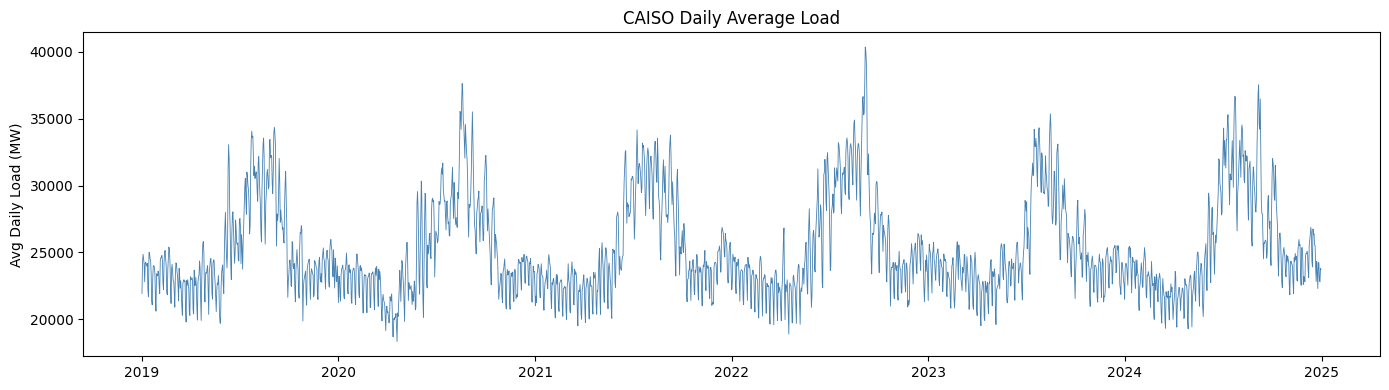

In [5]:
import matplotlib.pyplot as plt

# Daily average for a readable plot
hourly['date'] = pd.to_datetime(hourly['datetime']).dt.date
daily = hourly.groupby('date')['load_mw'].mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily.index, daily.values, linewidth=0.6, color='steelblue')
ax.set_ylabel('Avg Daily Load (MW)')
ax.set_title('CAISO Daily Average Load')
plt.tight_layout()
plt.show()